In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import requests
import json
import csv
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from io import StringIO
from tqdm import tqdm

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import RandomizedSearchCV

In [124]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Data Collecting and Loading

In [125]:
# Mengubah hasil scraping menjadi DataFrame
df_scrap = pd.read_csv('dataset.csv')
df_content = df_scrap[["content"]]
df_content.head()

,content
0,saya ini pengguna setia aplikasi shopee dari 2...
1,"aku suka Lo sama shopee, sering belanja ini it..."
2,"Aplikasi belanja paling top. Tolong di rubah, ..."
3,"Shope skrng pengiriman nya sngt lambat, paket ..."
4,Semakin sering dibuat belanja semakin dipersul...


# EDA & Cleaning

## Text Processing

In [126]:
df_content.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  11000 non-null  object
dtypes: object(1)
memory usage: 86.1+ KB


In [127]:
# Pembersihan teks kosong atau duplikat
df_clean = df_content.dropna()
df_clean = df_clean.drop_duplicates()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  11000 non-null  object
dtypes: object(1)
memory usage: 86.1+ KB


In [128]:
# Ambil translator slang dari github
url = 'https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_slang_words.txt'
r = requests.get(url)
# load json ke dict
slang_dict = json.loads(r.text)

# Setup stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Setup stopwords
listStopwords = set(stopwords.words('indonesian'))
listStopwords.update(set(stopwords.words('english')))

In [129]:
def preprocess_text(text, slang=None):
    text = text.lower()

    # Slang replacement
    if slang:
        words = text.split()
        text = " ".join([slang.get(word, word) for word in words])

    # Hapus angka
    text = "".join([char for char in text if not char.isdigit()])

    # Hapus URL
    text = re.sub(r'http\S+', '', text)

    # Hapus tanda baca
    punctuation = set(string.punctuation)
    text = "".join([char for char in text if char not in punctuation])

    # Normalisasi spasi
    text = " ".join(text.split())

    # Tokenisasi
    tokens = word_tokenize(text)

    # Hapus stopwords
    tokens = [word for word in tokens if word not in listStopwords]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return tokens

In [130]:
tqdm.pandas()
df_processed = df_clean['content'].progress_apply(lambda x: preprocess_text(x, slang=slang_dict))

100%|██████████| 11000/11000 [39:24<00:00,  4.65it/s]


In [131]:
# Fungsi menyambungkan kata di list ke bentuk string
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [132]:
df_copy = df_processed.to_frame()
df_copy["sentence"] = df_copy['content'].apply(toSentence)
df_copy.head()

,content,sentence
0,"[guna, setia, aplikasi, shopee, kesini, sistem...",guna setia aplikasi shopee kesini sistem kirim...
1,"[suka, shopee, belanja, layan, bagus, kurir, l...",suka shopee belanja layan bagus kurir langgan ...
2,"[aplikasi, belanja, top, tolong, rubah, jaring...",aplikasi belanja top tolong rubah jaring lanca...
3,"[shope, skrng, kirim, nya, sngt, lambat, paket...",shope skrng kirim nya sngt lambat paket minggu...
4,"[belanja, sulit, akun, toko, buka, toko, urus,...",belanja sulit akun toko buka toko urus gratis ...


In [133]:
# Lexicon positif
url_positive = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
df_pos = pd.read_csv(url_positive, header=None)
positive_lexicon = dict(zip(df_pos[0], df_pos[1]))

# Lexicon negatif
url_negative = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'
df_neg = pd.read_csv(url_negative, header=None)
negative_lexicon = dict(zip(df_neg[0], df_neg[1]))

In [134]:
# stemming lexicon agar hasil stem sebelumnya terdeteksi
pos_lex = {stemmer.stem(k): v for k, v in positive_lexicon.items()}
neg_lex = {stemmer.stem(k): v for k, v in negative_lexicon.items()}

In [135]:
# Untuk melakukan lexicon
def lexAnalysis(text):
    # Perhitungan skor
    score = 0
    for word in text:
        if word in pos_lex:
            score += pos_lex[word]

        elif word in neg_lex:
            score += neg_lex[word]

    # Labelin dari hasil score
    polarity = 0
    if score > 0:
        polarity = "positif"
    elif score < 0:
        polarity = "negatif"
    else:
      polarity = "netral"

    return score, polarity

## Lexicon Result

In [136]:
# Membuat kolom baru untuk score dan polarity
result = list(zip(*df_copy["content"].apply(lexAnalysis)))

df_copy["score"] = result[0]
df_copy["polarity"] = result[1]
df_copy.head()

,content,sentence,score,polarity
0,"[guna, setia, aplikasi, shopee, kesini, sistem...",guna setia aplikasi shopee kesini sistem kirim...,46,positif
1,"[suka, shopee, belanja, layan, bagus, kurir, l...",suka shopee belanja layan bagus kurir langgan ...,35,positif
2,"[aplikasi, belanja, top, tolong, rubah, jaring...",aplikasi belanja top tolong rubah jaring lanca...,23,positif
3,"[shope, skrng, kirim, nya, sngt, lambat, paket...",shope skrng kirim nya sngt lambat paket minggu...,34,positif
4,"[belanja, sulit, akun, toko, buka, toko, urus,...",belanja sulit akun toko buka toko urus gratis ...,33,positif


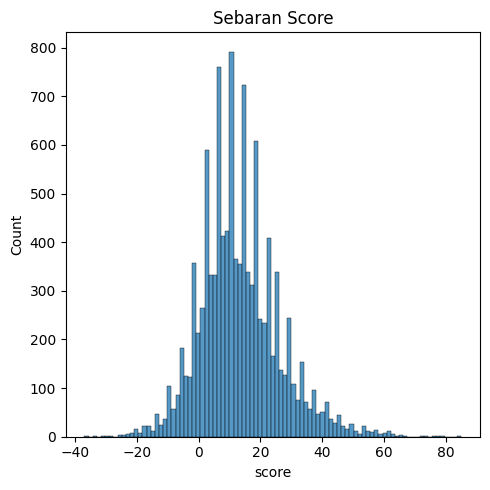

In [137]:
# Membuat sebaran distribusi score
plt.figure(figsize=(5,5))
sns.histplot(df_copy['score'])
plt.title("Sebaran Score")
plt.tight_layout()
plt.show()

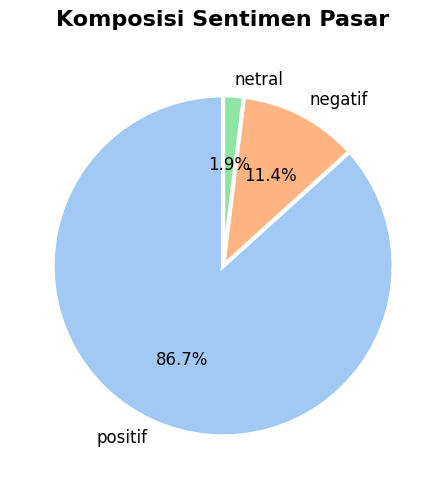

In [138]:
# Membuat pie chart perbandingan hasil polarity
x_pie = list(df_copy["polarity"].value_counts())
labels_pie = df_copy["polarity"].value_counts().index

colors = sns.color_palette("pastel")[0:len(labels_pie)]

plt.figure(figsize=(5, 5))
plt.pie(x=x_pie,
        labels=labels_pie,
        colors=colors,
        autopct='%.1f%%',
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': '500'},
        wedgeprops={'linewidth': 3, 'edgecolor': 'white'}
       )

plt.title('Komposisi Sentimen Pasar', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

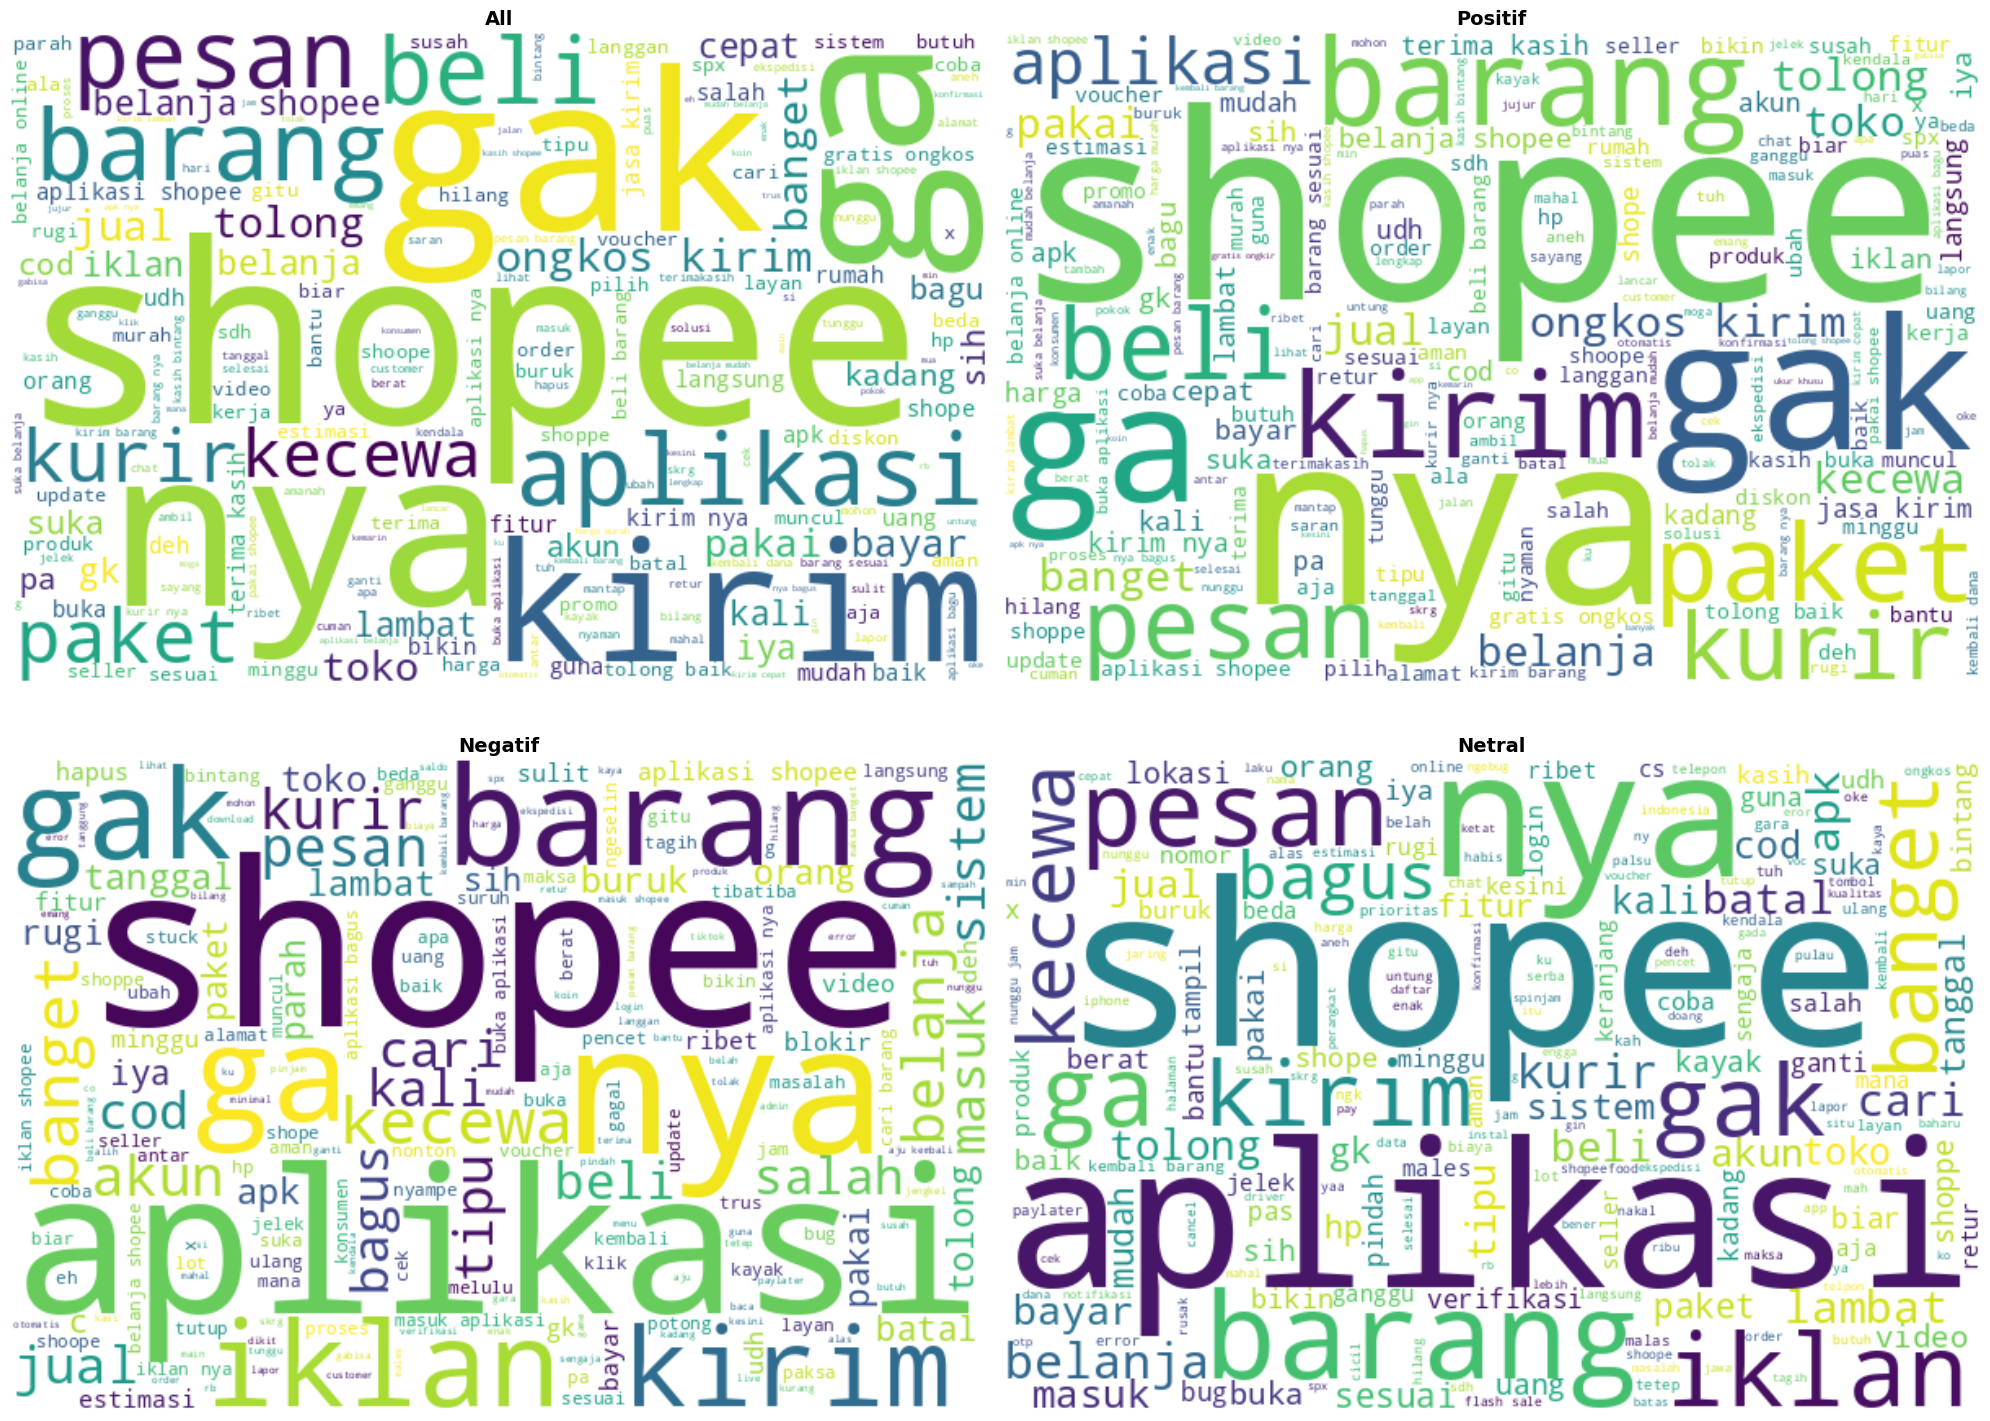

In [139]:
teks_all = " ".join(df_copy['sentence'])
teks_neg = " ".join(df_copy[df_copy['polarity'] == 'negatif']['sentence'])
teks_pos = " ".join(df_copy[df_copy['polarity'] == 'positif']['sentence'])
teks_net = " ".join(df_copy[df_copy['polarity'] == 'netral']['sentence'])

# membuat wordcloud untuk [keseluruhan, positif, negatif, dan netral]
kategori = {
    'All': teks_all,
    'Positif': teks_pos,
    'Negatif': teks_neg,
    'Netral' : teks_net
}

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, (label, teks) in enumerate(kategori.items()):
    wc = WordCloud(width=600, height=400, background_color='white').generate(teks)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(label, fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Modelling & Feature Extraction

In [140]:
# Pisahkan label dengan fitur
df_copy['polarity_encoded'] = df_copy['polarity'].map({
    'negatif': 0,
    'netral': 1,
    'positif' : 2,
})

# Inisialisasi label dan fitur
X = df_copy["sentence"]
y = df_copy["polarity_encoded"]

## Finding Model



### Imbalanced with SMOTE + TFIDF

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

In [142]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=3000, min_df=15, max_df=0.80)
X_train_tf = tfidf.fit_transform(X_train)

sm = SMOTE(random_state=42)
X_train_tfres, y_train_tfres = sm.fit_resample(X_train_tf, y_train)
X_test_tf = tfidf.transform(X_test)

# Model untuk SMOTE
tf_lr_base = LogisticRegression()
tf_nb_base = GaussianNB()

tf_lr_base.fit(X_train_tfres, y_train_tfres)
tf_nb_base.fit(X_train_tfres.toarray(), y_train_tfres)

# Prediksi
y_pred_lr = tf_lr_base.predict(X_test_tf)
y_pred_nb = tf_nb_base.predict(X_test_tf.toarray())

# Hitung skor untuk Logistic Regression (SMOTE)
acc_lr = accuracy_score(y_test, y_pred_lr)
pre_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

# Hitung skor untuk GaussianNB (SMOTE)
acc_nb = accuracy_score(y_test, y_pred_nb)
pre_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print("--- Hasil Akhir Test Set ---")
print(f"LR  -> Acc: {acc_lr:.3f}, Precision: {pre_lr:.3f}, Recall: {rec_lr:.3f}, F1: {f1_lr:.3f}")
print(f"GNB -> Acc: {acc_nb:.3f}, Precision: {pre_nb:.3f}, Recall: {rec_nb:.3f}, F1: {f1_nb:.3f}")

--- Hasil Akhir Test Set ---
LR  -> Acc: 0.870, Precision: 0.913, Recall: 0.870, F1: 0.888
GNB -> Acc: 0.524, Precision: 0.820, Recall: 0.524, F1: 0.613


### Imbalaced with Class Weight + TFIDF

In [143]:
# Model dengan Weight Class
lr_cw = LogisticRegression(class_weight='balanced')
nb_cw = ComplementNB() # karena nb tidak ada class_weight maka pake ComplementNB

lr_cw.fit(X_train_tf, y_train)
nb_cw.fit(X_train_tf, y_train)

# Prediksi ke X_test_tf
y_pred_lr_cw = lr_cw.predict(X_test_tf)
y_pred_nb_cw = nb_cw.predict(X_test_tf)

# Hitung skor untuk Logistic Regression (Class Weight)
acc_lr_cw = accuracy_score(y_test, y_pred_lr_cw)
pre_lr_cw = precision_score(y_test, y_pred_lr_cw, average='weighted')
rec_lr_cw = recall_score(y_test, y_pred_lr_cw, average='weighted')
f1_lr_cw = f1_score(y_test, y_pred_lr_cw, average='weighted')

# Hitung skor untuk ComplementNB
acc_nb_cw = accuracy_score(y_test, y_pred_nb_cw)
pre_nb_cw = precision_score(y_test, y_pred_nb_cw, average='weighted')
rec_nb_cw = recall_score(y_test, y_pred_nb_cw, average='weighted')
f1_nb_cw = f1_score(y_test, y_pred_nb_cw, average='weighted')

print("--- Hasil Akhir Test Set (Class Weight / No SMOTE) ---")
print(f"LR CW  -> Acc: {acc_lr_cw:.3f}, Precision: {pre_lr_cw:.3f}, Recall: {rec_lr_cw:.3f}, F1: {f1_lr_cw:.3f}")
print(f"CNB    -> Acc: {acc_nb_cw:.3f}, Precision: {pre_nb_cw:.3f}, Recall: {rec_nb_cw:.3f}, F1: {f1_nb_cw:.3f}")

--- Hasil Akhir Test Set (Class Weight / No SMOTE) ---
LR CW  -> Acc: 0.838, Precision: 0.913, Recall: 0.838, F1: 0.868
CNB    -> Acc: 0.775, Precision: 0.880, Recall: 0.775, F1: 0.807


### BOW + SMOTE

In [144]:
# Ekstraksi fitur dengan BoW
bow = CountVectorizer(max_features=3000, min_df=15, max_df=0.80)
X_train_bow = bow.fit_transform(X_train)

# SMOTE untuk BoW
X_train_bowres, y_train_bowres = sm.fit_resample(X_train_bow, y_train)
X_test_bow = tfidf.transform(X_test)

# Model untuk BoW dan SMOTE
bow_lr_base = LogisticRegression()
bow_nb_base = GaussianNB()

bow_lr_base.fit(X_train_bowres, y_train_bowres)
bow_nb_base.fit(X_train_bowres.toarray(), y_train_bowres)

# Prediksi
y_pred_bow_lr = bow_lr_base.predict(X_test_bow)
y_pred_bow_nb = bow_nb_base.predict(X_test_bow.toarray())

# Hitung skor untuk Logistic Regression (BoW + SMOTE)
acc_bow_lr = accuracy_score(y_test, y_pred_bow_lr)
pre_bow_lr = precision_score(y_test, y_pred_bow_lr, average='weighted')
rec_bow_lr = recall_score(y_test, y_pred_bow_lr, average='weighted')
f1_bow_lr = f1_score(y_test, y_pred_bow_lr, average='weighted')

# Hitung skor untuk GaussianNB (BoW + SMOTE)
acc_bow_nb = accuracy_score(y_test, y_pred_bow_nb)
pre_bow_nb = precision_score(y_test, y_pred_bow_nb, average='weighted')
rec_bow_nb = recall_score(y_test, y_pred_bow_nb, average='weighted')
f1_bow_nb = f1_score(y_test, y_pred_bow_nb, average='weighted')

print("--- Hasil Akhir Test Set (BoW + SMOTE) ---")
print(f"LR BoW  -> Acc: {acc_bow_lr:.3f}, Precision: {pre_bow_lr:.3f}, Recall: {rec_bow_lr:.3f}, F1: {f1_bow_lr:.3f}")
print(f"GNB BoW -> Acc: {acc_bow_nb:.3f}, Precision: {pre_bow_nb:.3f}, Recall: {rec_bow_nb:.3f}, F1: {f1_bow_nb:.3f}")

--- Hasil Akhir Test Set (BoW + SMOTE) ---
LR BoW  -> Acc: 0.277, Precision: 0.893, Recall: 0.277, F1: 0.355
GNB BoW -> Acc: 0.268, Precision: 0.815, Recall: 0.268, F1: 0.326


### BOW + Class Weight

In [145]:
# Ekstraksi fitur dengan BoW
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# Model dengan weight class (Tanpa SMOTE)
lr_bow_cw = LogisticRegression(class_weight='balanced', random_state=42)
nb_bow_cw = ComplementNB() # Pake ComplementNB karena jauh lebih sakti buat BoW imbalanced

# Fit
lr_bow_cw.fit(X_train_bow, y_train)
nb_bow_cw.fit(X_train_bow, y_train)

# Prediksi
y_pred_lr_bow = lr_bow_cw.predict(X_test_bow)
y_pred_nb_bow = nb_bow_cw.predict(X_test_bow)

# Hitung skor untuk Logistic Regression
acc_lrb = accuracy_score(y_test, y_pred_lr_bow)
pre_lrb = precision_score(y_test, y_pred_lr_bow, average='weighted')
rec_lrb = recall_score(y_test, y_pred_lr_bow, average='weighted')
f1_lrb = f1_score(y_test, y_pred_lr_bow, average='weighted')

# Hitung skor untuk ComplementNB
acc_nbb = accuracy_score(y_test, y_pred_nb_bow)
pre_nbb = precision_score(y_test, y_pred_nb_bow, average='weighted')
rec_nbb = recall_score(y_test, y_pred_nb_bow, average='weighted')
f1_nbb = f1_score(y_test, y_pred_nb_bow, average='weighted')

print("--- Hasil Akhir Test Set (BoW + Class Weight) ---")
print(f"LR BoW CW  -> Acc: {acc_lrb:.3f}, Precision: {pre_lrb:.3f}, Recall: {rec_lrb:.3f}, F1: {f1_lrb:.3f}")
print(f"CNB BoW    -> Acc: {acc_nbb:.3f}, Precision: {pre_nbb:.3f}, Recall: {rec_nbb:.3f}, F1: {f1_nbb:.3f}")

--- Hasil Akhir Test Set (BoW + Class Weight) ---
LR BoW CW  -> Acc: 0.864, Precision: 0.916, Recall: 0.864, F1: 0.885
CNB BoW    -> Acc: 0.802, Precision: 0.880, Recall: 0.802, F1: 0.825


# Main Model

In [146]:
params = {
    'C': np.logspace(-3, 3, 10),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

lr = LogisticRegression()

model = RandomizedSearchCV(
    estimator=lr,
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

model.fit(X_train_tfres, y_train_tfres)
print(f"Skor terbaik saat Tuning (CV): {model.best_score_:.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Skor terbaik saat Tuning (CV): 0.974


Accuracy: 0.8939
Precision (negatif, netral, positif): 0.9104922707881201
Recall (negatif, netral, positif): 0.8939393939393939
F1-Score (negatif, netral, positif): 0.9014999498526053


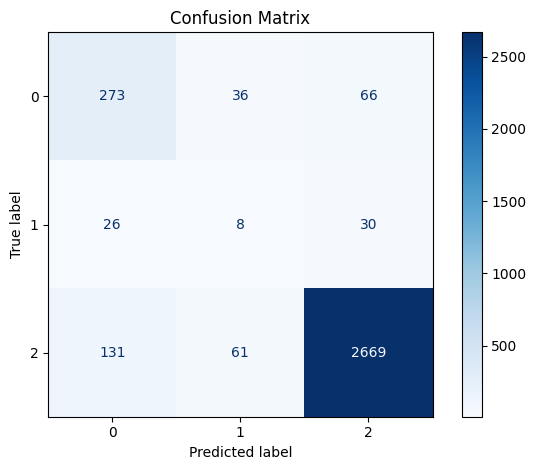

In [147]:
y_pred = model.predict(X_test_tf)

# Menghitung evaulasi klasifikasi
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred,)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (negatif, netral, positif): {precision}")
print(f"Recall (negatif, netral, positif): {recall}")
print(f"F1-Score (negatif, netral, positif): {f1}")

# Hasil klasifikasi di Confusion matrix
cm = confusion_matrix(y_test_tf, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Model Prediction

In [148]:
# Tentukan teks baru untuk diprediksi
text = "aplIkasinya bagus dan bikin mudah belanja @pakwo, 124. https//"

In [149]:
# Preprocessing teks
processed_text = preprocess_text(text, slang=slang_dict)
sentence_text = toSentence(processed_text)

# Transformasi dengan TF-IDF
X_new = tfidf.transform([sentence_text])

# Prediksi menggunakan model
prediction_encoded = model.predict(X_new)

# Dekode hasil prediksi kembali ke label sentimen
polarity_map = {
    0: 'negatif',
    1: 'netral',
    2: 'positif'
}

predicted_polarity = polarity_map[prediction_encoded[0]]

print(f"Teks: '{text}'")
print(f"Prediksi Sentimen: {predicted_polarity}")

Teks: 'aplIkasinya bagus dan bikin mudah belanja @pakwo, 124. https//'
Prediksi Sentimen: positif
